# NTDS Inference
Loads a `.ntds` feather file, preprocesses to match training format, runs the DSTformer backbone, and extracts embeddings.

In [11]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from model.architecture.motionBert_full import DSTformer, ReconstructNet
from model.inference.extract_and_eval import (
    _load_checkpoint_for_inference,
    _pool_v1_batch, _pool_v2_batch, _pool_v4_batch,
    NOISE_JOINT_NAMES,
)
from model.preprocessing.joints_file import noise_joints  # [8, 9, 10, 15, 16, 17]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Config

In [24]:
NTDS_FILE     = "../ntds/K4A000068715312_HPECONFIG_2025-06-04T16_01_10Z.ntds"
CSV_FILE = "../sample_data/self_selected_gait_speed/front__2024-01-09.csv"
CHECKPOINT    = "../model/published/epoch_31.pth"

# Must match training config (from model_args.txt)
SEQ_LEN       = 900    # size_seq
DIM_IN        = 4      # x, y, z, confidence per joint
DIM_FEAT      = 128    # backbone hidden dim (inferred from checkpoint)
DIM_REP       = 32     # dim_representation
NUM_HEADS     = 8
DEPTH         = 8      # inferred from checkpoint (8 blocks_st + 8 blocks_ts)
NUM_JOINTS    = 26     # 32 k4abt joints minus 6 hand noise joints
CENTROID_JOINT = 0     # PELVIS (centroid_type='second' -> joints_centroid2=[PELVIS])

In [25]:
df = pd.read_csv(CSV_FILE)
df.head(3)

,FrameNumber,timestamp_usec,0_PELVIS_x,0_PELVIS_y,0_PELVIS_z,0_PELVIS_c,0_PELVIS_angle_w,0_PELVIS_angle_x,0_PELVIS_angle_y,0_PELVIS_angle_z,...,30_EYE_RIGHT_angle_y,30_EYE_RIGHT_angle_z,31_EAR_RIGHT_x,31_EAR_RIGHT_y,31_EAR_RIGHT_z,31_EAR_RIGHT_c,31_EAR_RIGHT_angle_w,31_EAR_RIGHT_angle_x,31_EAR_RIGHT_angle_y,31_EAR_RIGHT_angle_z
0,0.0,3.480902e+09,-29.463312,-383.144501,2376.907227,2.0,0.507424,-0.472701,0.552323,-0.462617,...,0.671845,0.058707,-136.794708,-1112.292725,2280.396484,2.0,0.559834,-0.412370,0.537763,-0.476810
1,1.0,3.480935e+09,-33.180584,-381.965332,2382.507568,2.0,0.520162,-0.464064,0.544017,-0.467035,...,0.658824,0.067281,-136.082047,-1114.263794,2274.193848,2.0,0.571513,-0.387114,0.544604,-0.476363
2,2.0,3.480969e+09,-31.490639,-381.192627,2386.478516,2.0,0.531457,-0.460369,0.537861,-0.465101,...,0.658032,0.053872,-132.871506,-1118.017334,2275.578857,2.0,0.563042,-0.384834,0.545764,-0.486855


## Load & Preprocess NTDS

In [3]:
df = pd.read_feather(NTDS_FILE)
print(f"Loaded {len(df)} frames, {len(df.columns)} columns")
df.head(3)

Loaded 1830 frames, 259 columns


/Users/nitsantzur/opt/GaitPredict/venv/lib/python3.11/site-packages/pandas/io/feather_format.py:178: FutureWarning: pyarrow.feather.read_table is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  pa_table = feather.read_table(


,FrameNumber,timestamp_usec,body_id,0_PELVIS_x,0_PELVIS_y,0_PELVIS_z,0_PELVIS_c,0_PELVIS_angle_w,0_PELVIS_angle_x,0_PELVIS_angle_y,...,30_EYE_RIGHT_angle_y,30_EYE_RIGHT_angle_z,31_EAR_RIGHT_x,31_EAR_RIGHT_y,31_EAR_RIGHT_z,31_EAR_RIGHT_c,31_EAR_RIGHT_angle_w,31_EAR_RIGHT_angle_x,31_EAR_RIGHT_angle_y,31_EAR_RIGHT_angle_z
0,0.0,233600333.0,1.0,-36.544479,-243.229156,2304.473633,2.0,0.725724,-0.015402,0.009648,...,0.194473,-0.104395,-51.359871,-956.865479,2283.002686,2.0,0.581100,-0.353668,-0.078642,-0.728737
1,1.0,233633677.0,1.0,-38.475266,-239.880112,2303.299072,2.0,0.726854,-0.006398,-0.006157,...,0.186788,-0.103333,-47.888660,-956.594421,2282.751709,2.0,0.581427,-0.353108,-0.088949,-0.727562
2,2.0,233667000.0,1.0,-37.722900,-238.190720,2308.228271,2.0,0.732991,0.025110,-0.000674,...,0.176889,-0.124085,-46.881985,-946.166077,2274.479980,2.0,0.557179,-0.371521,-0.121363,-0.732663


In [26]:
import enum

class k4abt_joints(enum.IntEnum):
    PELVIS=0; SPINE_NAVEL=1; SPINE_CHEST=2; NECK=3
    CLAVICLE_LEFT=4; SHOULDER_LEFT=5; ELBOW_LEFT=6; WRIST_LEFT=7
    HAND_LEFT=8; HANDTIP_LEFT=9; THUMB_LEFT=10
    CLAVICLE_RIGHT=11; SHOULDER_RIGHT=12; ELBOW_RIGHT=13; WRIST_RIGHT=14
    HAND_RIGHT=15; HANDTIP_RIGHT=16; THUMB_RIGHT=17
    HIP_LEFT=18; KNEE_LEFT=19; ANKLE_LEFT=20; FOOT_LEFT=21
    HIP_RIGHT=22; KNEE_RIGHT=23; ANKLE_RIGHT=24; FOOT_RIGHT=25
    HEAD=26; NOSE=27; EYE_LEFT=28; EAR_LEFT=29; EYE_RIGHT=30; EAR_RIGHT=31

# noise_joints from joints_file.py: [8, 9, 10, 15, 16, 17]
keep_joints = [j for j in range(32) if j not in noise_joints]
print(f"Keeping {len(keep_joints)} joints: {keep_joints}")

def extract_pose_array(df: pd.DataFrame) -> np.ndarray:
    """Returns array of shape [T, 32, 4] with (x, y, z, confidence) per joint."""
    T = len(df)
    arr = np.zeros((T, 32, 4), dtype=np.float32)
    for joint in k4abt_joints:
        idx = joint.value
        name = joint.name
        arr[:, idx, 0] = df[f"{idx}_{name}_x"].values
        arr[:, idx, 1] = df[f"{idx}_{name}_y"].values
        arr[:, idx, 2] = df[f"{idx}_{name}_z"].values
        arr[:, idx, 3] = df[f"{idx}_{name}_c"].values
    return arr

pose_all = extract_pose_array(df)              # [T, 32, 4]
pose_kept = pose_all[:, keep_joints, :]        # [T, 26, 4]

# Center on PELVIS (joint index 0 in original, which maps to index 0 in keep_joints)
pelvis_idx_in_kept = keep_joints.index(CENTROID_JOINT)
centroid = pose_kept[:, pelvis_idx_in_kept:pelvis_idx_in_kept+1, :3]  # [T, 1, 3]
pose_kept[:, :, :3] -= centroid

print(f"Pose array shape after joint selection and centering: {pose_kept.shape}")
print(f"XYZ range: [{pose_kept[:,:,:3].min():.3f}, {pose_kept[:,:,:3].max():.3f}]")

Keeping 26 joints: [0, 1, 2, 3, 4, 5, 6, 7, 11, 12, 13, 14, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
Pose array shape after joint selection and centering: (1829, 26, 4)
XYZ range: [-771.932, 1029.617]


In [27]:
def chunk_sequence(arr: np.ndarray, seq_len: int) -> np.ndarray:
    """Split [T, J, C] into non-overlapping chunks of seq_len, padding last chunk if needed."""
    T, J, C = arr.shape
    n_full = T // seq_len
    remainder = T % seq_len

    chunks = [arr[i * seq_len:(i + 1) * seq_len] for i in range(n_full)]

    if remainder > 0:
        pad = np.zeros((seq_len - remainder, J, C), dtype=arr.dtype)
        chunks.append(np.concatenate([arr[n_full * seq_len:], pad], axis=0))

    return np.stack(chunks, axis=0)  # [N, seq_len, J, C]

chunks = chunk_sequence(pose_kept, SEQ_LEN)   # [N, 900, 26, 4]
print(f"Chunks shape: {chunks.shape}  ({chunks.shape[0]} sequences of {SEQ_LEN} frames)")

Chunks shape: (3, 900, 26, 4)  (3 sequences of 900 frames)


## Load Model

In [28]:
backbone = DSTformer(
    dim_in=DIM_IN,
    dim_feat=DIM_FEAT,
    dim_rep=DIM_REP,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    num_joints=NUM_JOINTS,
    maxlen=SEQ_LEN,
    use_rope=True,
    use_flash_attn=False,
)
model = ReconstructNet(
    model_backbone=backbone,
    dim_in=DIM_IN,
    dim_out=3,
    modality_dropout_prob=0.0,
)
model = _load_checkpoint_for_inference(model, CHECKPOINT, device)
model.eval()
print("Model loaded.")

Loading checkpoint from ../model/published/epoch_31.pth
Model loaded.


## Run Inference

In [20]:
data_tensor = torch.tensor(chunks, dtype=torch.float32).to(device)  # [N, T, J, 4]

all_v1, all_v2, all_prelogits = [], [], []

BATCH_SIZE = 4

with torch.no_grad():
    for i in range(0, len(data_tensor), BATCH_SIZE):
        batch = data_tensor[i:i + BATCH_SIZE]
        _, bundle = model(batch, mask=None)

        block_emb    = bundle['block_embeddings']       # [B, T, J, dim_feat]
        prelogits    = bundle['pre_logits_embeddings']  # [B, T, J, dim_rep]

        all_v1.append(_pool_v1_batch(block_emb))    # [B, 2*dim_feat]
        all_v2.append(_pool_v2_batch(block_emb))    # [B, 3*dim_feat]
        all_prelogits.append(_pool_v4_batch(prelogits))  # [B, J*dim_rep]

emb_v1       = np.concatenate(all_v1, axis=0)        # [N, 2*128]
emb_v2       = np.concatenate(all_v2, axis=0)        # [N, 3*128]
emb_prelogits = np.concatenate(all_prelogits, axis=0) # [N, 26*32]

print(f"Embeddings:")
print(f"  v1 (mean+max):        {emb_v1.shape}")
print(f"  v2 (mean/max/std):    {emb_v2.shape}")
print(f"  prelogits per joint:  {emb_prelogits.shape}")

Embeddings:
  v1 (mean+max):        (3, 256)
  v2 (mean/max/std):    (3, 384)
  prelogits per joint:  (3, 832)


## Visualize Embeddings

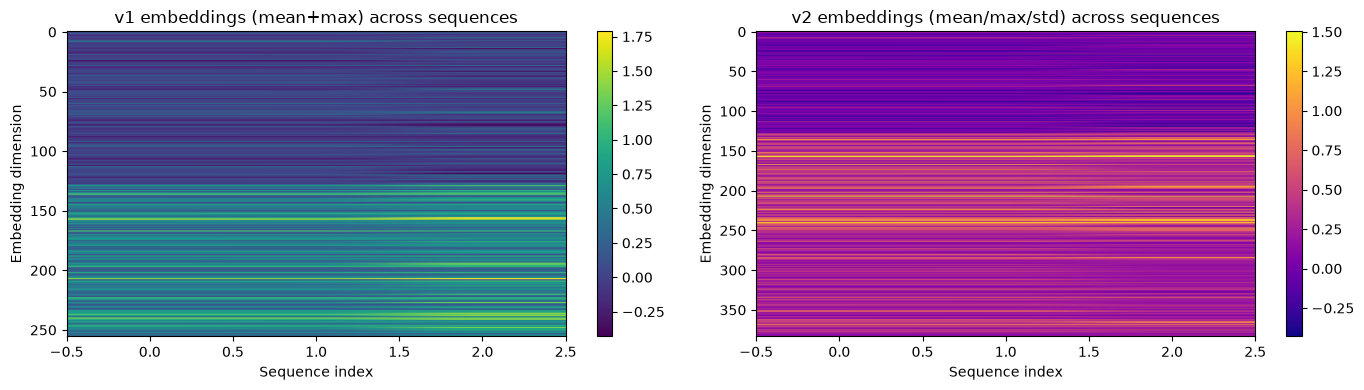

In [21]:
# Per-sequence mean embedding (v1) as a heatmap over time
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im0 = axes[0].imshow(emb_v1.T, aspect='auto', cmap='viridis')
axes[0].set_title("v1 embeddings (mean+max) across sequences")
axes[0].set_xlabel("Sequence index")
axes[0].set_ylabel("Embedding dimension")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(emb_v2.T, aspect='auto', cmap='plasma')
axes[1].set_title("v2 embeddings (mean/max/std) across sequences")
axes[1].set_xlabel("Sequence index")
axes[1].set_ylabel("Embedding dimension")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

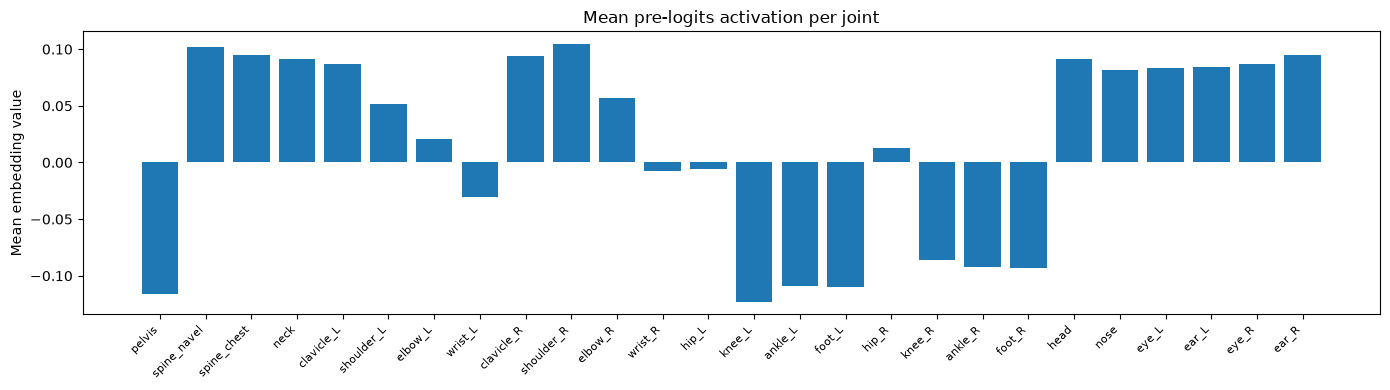

In [22]:
# Per-joint pre_logits: reshape to [N, J, dim_rep] and show mean per joint
prelogits_per_joint = emb_prelogits.reshape(len(emb_prelogits), NUM_JOINTS, DIM_REP)
joint_mean = prelogits_per_joint.mean(axis=(0, 2))  # mean over sequences and dims -> [J]
joint_names = [NOISE_JOINT_NAMES[j] for j in range(NUM_JOINTS)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(NUM_JOINTS), joint_mean)
ax.set_xticks(range(NUM_JOINTS))
ax.set_xticklabels(joint_names, rotation=45, ha='right', fontsize=8)
ax.set_title("Mean pre-logits activation per joint")
ax.set_ylabel("Mean embedding value")
plt.tight_layout()
plt.show()

## Save Embeddings

In [23]:
import os

out_stem = os.path.splitext(os.path.basename(NTDS_FILE))[0]

v1_cols = ([f"emb_mean_{i}" for i in range(DIM_FEAT)] +
           [f"emb_max_{i}" for i in range(DIM_FEAT)])
v4_cols = [f"emb_{NOISE_JOINT_NAMES[j]}_{i}" for j in range(NUM_JOINTS) for i in range(DIM_REP)]

df_v1 = pd.DataFrame(emb_v1, columns=v1_cols)
df_v1.insert(0, 'seq_idx', range(len(df_v1)))

df_v4 = pd.DataFrame(emb_prelogits, columns=v4_cols)
df_v4.insert(0, 'seq_idx', range(len(df_v4)))

df_v1.to_csv(f"../results/{out_stem}_emb_v1.csv", index=False)
df_v4.to_csv(f"../results/{out_stem}_emb_v4.csv", index=False)

print(f"Saved {out_stem}_emb_v1.csv  ({df_v1.shape})")
print(f"Saved {out_stem}_emb_v4.csv  ({df_v4.shape})")

Saved K4A000068715312_HPECONFIG_2025-06-04T16_01_10Z_emb_v1.csv  ((3, 257))
Saved K4A000068715312_HPECONFIG_2025-06-04T16_01_10Z_emb_v4.csv  ((3, 833))
